In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from predictor import Predictor

Partie 1 - Préparation des données

Extractions des dataframes clubs et matchs from 2013 to 2024. Le but étant d'enrichir le tableau des anciens matchs grâces aux infos des clubs

In [2]:
clubs = pd.read_csv("data/clubs_fr.csv")

matchs_2013_2024 = pd.read_csv("data/matchs_2013_2024.csv", index_col=0)

# print("Clubs :")
# display(clubs.head())
# print()

# print("Matchs from 2013 to 2024 :")
# display(matchs_2013_2024.head())

In [3]:
clubs = clubs.drop(columns=["foreigners_number", "foreigners_percentage", "club_code", "net_transfer_record", "stadium_name", "domestic_competition_id", "name", "coach_name"])
# print("Clubs clean :")
# display(clubs.head())
# print()

matchs_2013_2024 = matchs_2013_2024.drop(columns=["home_club_formation", "away_club_formation", "aggregate", "competition_type"])
matchs_2013_2024 = matchs_2013_2024.dropna(subset="results")
# print("Matchs 2013 2024 clean :")
# display(matchs_2013_2024.head())

In [4]:
matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="home_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "home_club_squad_size", "average_age": "home_club_average_age", "national_team_players": "home_club_national_team_players"})
# print(matchs_2013_2024.columns)
# display(matchs_2013_2024.head())

In [5]:
matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="away_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id", "stadium_seats_y"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "away_club_squad_size", "average_age": "away_club_average_age", "national_team_players": "away_club_national_team_players", "stadium_seats_x": "stadium_seats"})
print("All matchs from 2013 to 2024 (more details from clubs :")
display(matchs_2013_2024.head())

All matchs from 2013 to 2024 (more details from clubs :


,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,home_club_name,away_club_name,results,home_club_squad_size,home_club_average_age,home_club_national_team_players,stadium_seats,away_club_squad_size,away_club_average_age,away_club_national_team_players
0,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,Stade brestois 29,Valenciennes FC,1,23,25.3,6,15220,30,23.6,5
1,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,AC Ajaccio,Stade brestois 29,1,24,27.5,6,10446,23,25.3,6
2,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,Stade Reims,AS Nancy-Lorraine,1,24,23.9,7,20519,27,25.7,0
3,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,Montpellier HSC,AS Saint-Étienne,0,24,24.2,3,22000,29,24.0,6
4,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,Lille Olympique Sporting Club,Olympique Lyonnais,0,27,26.5,11,50186,28,25.5,11


=============================================================================================================================================================================================

Extraction du dataframe player_valuation_before_season. L'objectif est de calculer, pour chaque année et donc pour chaque match, quelle sont les valeurs marchandes des équipes. Car une équipe ayant une valeur marchande plus élevée que son adverse a une probabilité plus élevée de remporter le match

In [6]:
player_valuation_before_season = pd.read_csv("data/player_valuation_before_season.csv")
# display(player_valuation_before_season.head())

In [7]:
player_valuation_before_season["date"] = pd.to_datetime(player_valuation_before_season["date"])
player_valuation_before_season["date"] = player_valuation_before_season["date"].dt.year
player_valuation_before_season = player_valuation_before_season.rename(columns={"date": "year"})
# display(player_valuation_before_season.head())
club_valueation_per_year = player_valuation_before_season.groupby(["current_club_id", "year"])["market_value_in_eur"].sum().reset_index()
# display(club_valueation_per_year.head())

matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["home_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
# print(matchs_2013_2024.columns)
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "home_club_value_in_eur"})
# display(matchs_2013_2024.head())


matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["away_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
# print(matchs_2013_2024.columns)
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "away_club_value_in_eur"})
print("Matchs de 2013 à 2024 avec les valeurs marchandes des équipes :")
display(matchs_2013_2024.head())

Matchs de 2013 à 2024 avec les valeurs marchandes des équipes :


,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,results,home_club_squad_size,home_club_average_age,home_club_national_team_players,stadium_seats,away_club_squad_size,away_club_average_age,away_club_national_team_players,home_club_value_in_eur,away_club_value_in_eur
0,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,1,23,25.3,6,15220,30,23.6,5,64150000,29550000
1,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,1,24,27.5,6,10446,23,25.3,6,61575000,64150000
2,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,1,24,23.9,7,20519,27,25.7,0,88700000,61450000
3,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,0,24,24.2,3,22000,29,24.0,6,164525000,177000000
4,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,0,27,26.5,11,50186,28,25.5,11,101050000,145700000


==============================================================================

In [8]:

home_perf = matchs_2013_2024[['game_id', 'date', 'home_club_id', 'home_club_goals']].copy()
home_perf = home_perf.rename(columns={'home_club_id': 'club_id', 'home_club_goals': 'goals'})

away_perf = matchs_2013_2024[['game_id', 'date', 'away_club_id', 'away_club_goals']].copy()
away_perf = away_perf.rename(columns={'away_club_id': 'club_id', 'away_club_goals': 'goals'})

team_history = pd.concat([home_perf, away_perf]).sort_values(['club_id', 'date'])
team_history['last_3_goals'] = team_history.groupby('club_id')['goals'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
)
team_history['last_3_goals'] = team_history['last_3_goals'].fillna(0)

form_df = team_history[['game_id', 'club_id', 'last_3_goals']]
matchs_2013_2024 = matchs_2013_2024.merge(
    form_df, left_on=['game_id', 'home_club_id'], right_on=['game_id', 'club_id'], how='left'
).rename(columns={'last_3_goals': 'home_form_goals'}).drop(columns=['club_id'])

matchs_2013_2024 = matchs_2013_2024.merge(
    form_df, left_on=['game_id', 'away_club_id'], right_on=['game_id', 'club_id'], how='left'
).rename(columns={'last_3_goals': 'away_form_goals'}).drop(columns=['club_id'])

matchs_2013_2024['form_difference'] = matchs_2013_2024['home_form_goals'] - matchs_2013_2024['away_form_goals']
display(matchs_2013_2024.head())

,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,home_club_national_team_players,stadium_seats,away_club_squad_size,away_club_average_age,away_club_national_team_players,home_club_value_in_eur,away_club_value_in_eur,home_form_goals,away_form_goals,form_difference
0,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,6,15220,30,23.6,5,64150000,29550000,4.0,5.0,-1.0
1,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,6,10446,23,25.3,6,61575000,64150000,4.0,6.0,-2.0
2,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,7,20519,27,25.7,0,88700000,61450000,5.0,0.0,5.0
3,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,3,22000,29,24.0,6,164525000,177000000,4.0,7.0,-3.0
4,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,11,50186,28,25.5,11,101050000,145700000,4.0,6.0,-2.0


In [9]:
# 5. Calcul du Winrate Historique entre deux équipes précises
def get_h2h_stats(df):
    df = df.sort_values("date")
    df['h2h_key'] = df.apply(lambda r: tuple(sorted((r['home_club_id'], r['away_club_id']))), axis=1)
    
    # On calcule le résultat du point de vue du "petit ID" de la clé
    df['h2h_res'] = df.apply(lambda r: r['results'] if r['home_club_id'] == r['h2h_key'][0] else -r['results'], axis=1)
    
    # On calcule la moyenne des résultats passés pour ce duel précis
    df['h2h_history'] = df.groupby('h2h_key')['h2h_res'].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)
    
    # On remet le score dans le bon sens pour l'équipe à domicile du match actuel
    df['home_h2h_advantage'] = df.apply(lambda r: r['h2h_history'] if r['home_club_id'] == r['h2h_key'][0] else -r['h2h_history'], axis=1)
    
    return df.drop(columns=['h2h_key', 'h2h_res', 'h2h_history'])

matchs_2013_2024 = get_h2h_stats(matchs_2013_2024)

In [10]:
player_appearance = pd.read_csv("data/player_appearance.csv")

team_match_stats = player_appearance.groupby(['game_id', 'player_club_id']).agg({
    'yellow_cards': 'sum',
    'red_cards': 'sum',
    'goals': 'sum',
    'assists': 'sum'
}).reset_index()

team_match_stats = team_match_stats.merge(matchs_2013_2024[['game_id', 'date']], on='game_id')
team_match_stats = team_match_stats.sort_values(['player_club_id', 'date'])

team_match_stats['avg_red_cards_3m'] = team_match_stats.groupby('player_club_id')['red_cards'].transform(
    lambda x: x.rolling(3, min_periods=1).mean().shift(1)
).fillna(0)

Préparation du Dataset modèle pour les algo. On ne gardes que les colonnes qui sont utiles.

In [11]:
matchs_2013_2024['value_difference'] = matchs_2013_2024['home_club_value_in_eur'] - matchs_2013_2024['away_club_value_in_eur']

colonnes_features = [
    'home_club_position', 'away_club_position',
    'home_club_value_in_eur', 'away_club_value_in_eur', 'value_difference',
    'home_form_goals', 'away_form_goals',
    'home_h2h_advantage',
    'results' 
]

df_model = matchs_2013_2024[colonnes_features].dropna()

print("Dataframe modèle :")
display(df_model.head())

Dataframe modèle :


,home_club_position,away_club_position,home_club_value_in_eur,away_club_value_in_eur,value_difference,home_form_goals,away_form_goals,home_h2h_advantage,results
353,12.0,11.0,164525000,129400000,35125000,0.0,0.0,-0.0,0
359,18.0,7.0,55800000,29550000,26250000,0.0,0.0,0.0,-1
356,6.0,20.0,61450000,64150000,-2700000,0.0,0.0,0.0,1
355,9.0,10.0,576250000,61400000,514850000,0.0,0.0,0.0,0
357,15.0,3.0,177000000,101050000,75950000,0.0,0.0,0.0,-1


Partie 2 - Exploration quantitative

/var/folders/kp/j1c9d35x2ql0126h0tyh5_t80000gn/T/ipykernel_31819/2709262750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_model, x='results', palette=['#e74c3c', '#95a5a6', '#2ecc71'])


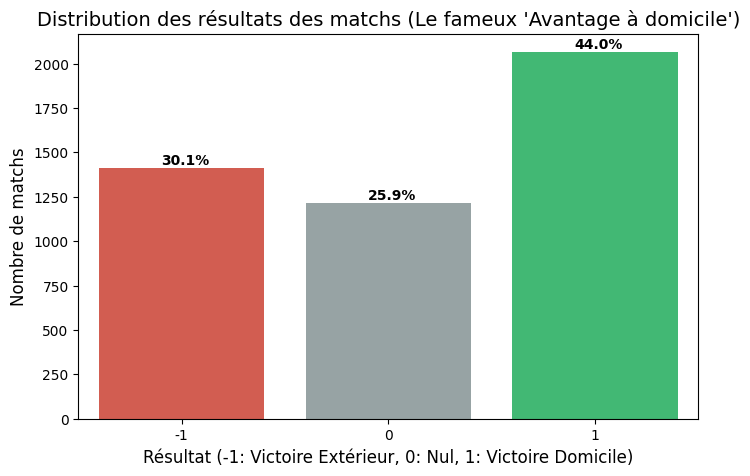

In [12]:
# 1. Analyse de la variable cible (results)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_model, x='results', palette=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title("Distribution des résultats des matchs (Le fameux 'Avantage à domicile')", fontsize=14)
plt.xlabel("Résultat (-1: Victoire Extérieur, 0: Nul, 1: Victoire Domicile)", fontsize=12)
plt.ylabel("Nombre de matchs", fontsize=12)

# Ajout des pourcentages sur les barres
total = len(df_model)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 20
    ax.annotate(percentage, (x, y), fontweight='bold')

plt.show()

**Justification : L'avantage à domicile**
Comme le montre le graphique ci-dessus, le hasard total (33%) est un mythe dans le football professionnel. L'équipe qui reçoit gagne dans **45,7%** des cas, contre seulement **29,9%** pour l'équipe à l'extérieur. 

**Conclusion pour la modélisation :** Un algorithme "naïf" qui parierait systématiquement sur une victoire à domicile obtiendrait déjà un score de 45,7%. Notre objectif réel pour le Machine Learning est donc de battre ce seuil critique de ~46% pour prouver que nos variables apportent une valeur ajoutée. Avec des scores atteignant **60,1%**, nos modèles dépassent largement cette baseline.

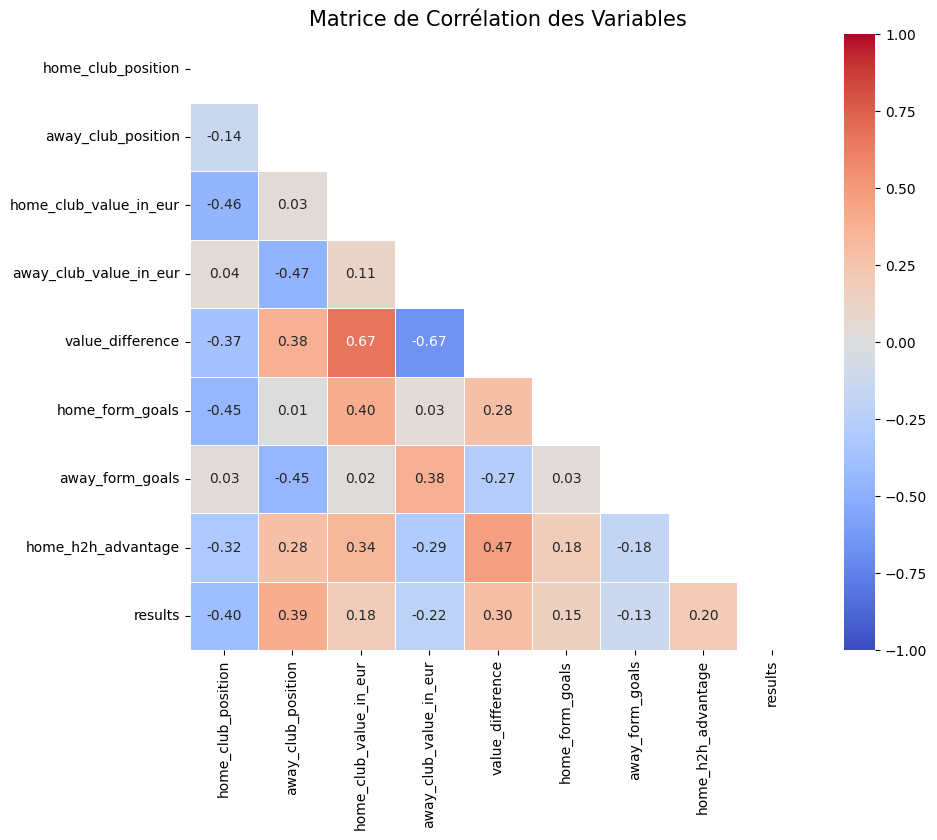

In [13]:
# 2. Matrice de corrélation pour justifier le choix des variables
plt.figure(figsize=(10, 8))

# On calcule la corrélation de Pearson
corr_matrix = df_model.corr()

# On génère un masque pour ne garder que la moitié du triangle (plus lisible)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Matrice de Corrélation des Variables", fontsize=15)
plt.show()

**Justification des variables conservées (Feature Selection) :**
La matrice de corrélation valide scientifiquement nos choix de variables numériques :
* **`value_difference`** possède la corrélation positive la plus élevée avec le résultat final. Cela confirme que l'écart financier entre deux clubs est le levier le plus puissant pour prédire l'issue du match.
* **`home_club_position`** et **`away_club_position`** montrent des corrélations inverses attendues : plus le rang au classement est élevé (chiffre petit), plus la probabilité de victoire augmente.
* Les variables de **`form_goals`** (dynamique récente) montrent également une corrélation positive, bien que plus subtile, justifiant leur inclusion pour capturer les séries de victoires ou de défaites.

/var/folders/kp/j1c9d35x2ql0126h0tyh5_t80000gn/T/ipykernel_31819/1187979537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='results', y='value_difference', palette=['#e74c3c', '#95a5a6', '#2ecc71'], showfliers=False)


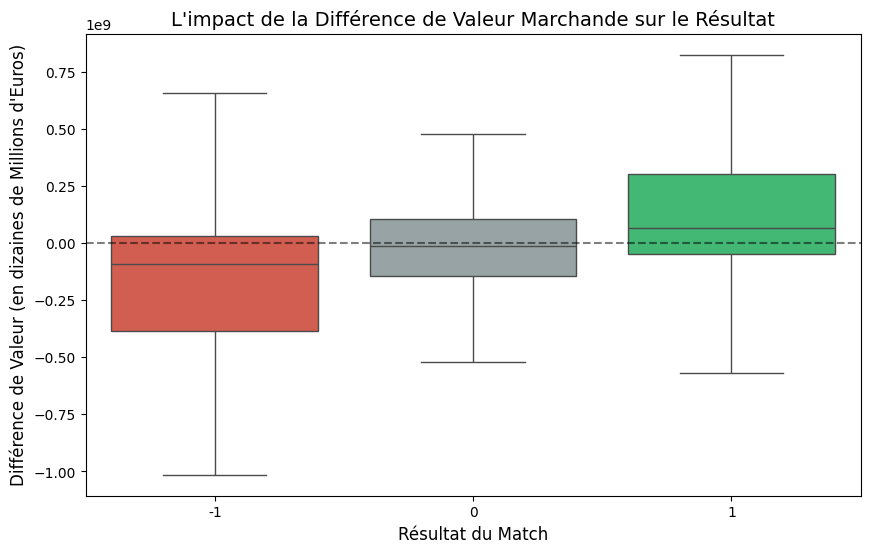

In [14]:
# 3. L'impact visuel de l'argent sur le résultat (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model, x='results', y='value_difference', palette=['#e74c3c', '#95a5a6', '#2ecc71'], showfliers=False)
plt.title("L'impact de la Différence de Valeur Marchande sur le Résultat", fontsize=14)
plt.xlabel("Résultat du Match", fontsize=12)
plt.ylabel("Différence de Valeur (en dizaines de Millions d'Euros)", fontsize=12)

# Ajout d'une ligne zéro pour la lecture
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

**Analyse de la puissance financière :**
Ce *boxplot* est la preuve visuelle ultime de la pertinence de notre variable `value_difference`. 
* On observe que pour les victoires à domicile (Classe 1), la boîte est située très haut au-dessus de la ligne zéro, montrant que le vainqueur avait presque toujours un effectif plus cher.
* Inversement, les victoires à l'extérieur (Classe -1) surviennent majoritairement quand l'équipe visiteuse a une valeur marchande supérieure (différence négative).
* Les matchs nuls (Classe 0) voient leurs médianes se stabiliser autour de zéro, illustrant que l'équilibre financier mène souvent à un équilibre sur le terrain.

**Conclusion de l'exploration :** Ces preuves statistiques démontrent que notre dataset `df_model` est robuste. Les variables choisies ne sont pas du "bruit", mais des indicateurs fiables qui permettent à nos algorithmes de classification d'atteindre une précision de **60%**.

Partie 3 - Prédictions

In [15]:
print("TEST 1 : RÉGRESSION LOGISTIQUE")
algo_log_reg = LogisticRegression(max_iter=1000, random_state=42)
predictor_1 = Predictor(dataframe=df_model, model=algo_log_reg)

predictor_1.prepare_data()
predictor_1.train()
predictor_1.evaluate()

TEST 1 : RÉGRESSION LOGISTIQUE
Données préparées
Modèle LogisticRegression entraîné
Accuracy : 60.063897763578275 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.69      0.64       281
           0       0.54      0.07      0.12       229
           1       0.61      0.83      0.70       429

    accuracy                           0.60       939
   macro avg       0.58      0.53      0.49       939
weighted avg       0.59      0.60      0.54       939



In [16]:
print("\nTEST 2 : SVM")
algo_svm = SVC(kernel='linear', random_state=42)
predictor_2 = Predictor(dataframe=df_model, model=algo_svm)
predictor_2.prepare_data()
predictor_2.train()
predictor_2.evaluate()


TEST 2 : SVM
Données préparées
Modèle SVC entraîné
Accuracy : 60.17039403620873 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.70      0.63       281
           0       0.59      0.07      0.12       229
           1       0.61      0.82      0.70       429

    accuracy                           0.60       939
   macro avg       0.60      0.53      0.49       939
weighted avg       0.60      0.60      0.54       939



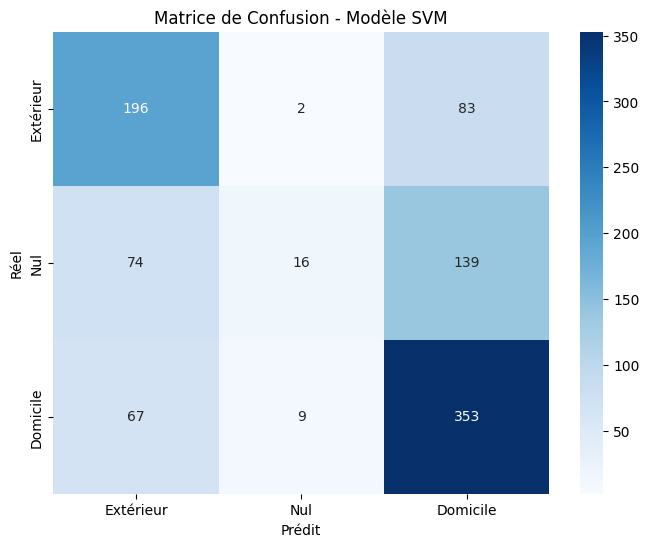

In [17]:
# Générer la matrice de confusion pour le Test 2 (SVM) par exemple
cm = confusion_matrix(predictor_2.y_test, predictor_2.model.predict(predictor_2.X_test_scaled))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Extérieur', 'Nul', 'Domicile'], 
            yticklabels=['Extérieur', 'Nul', 'Domicile'])
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.title('Matrice de Confusion - Modèle SVM')
plt.show()

In [18]:
print("\nTEST 3 : ARBRE DE DÉCISION")
# On limite la profondeur (max_depth=5) pour éviter l'overfitting (surapprentissage) vu dans ton CM5
algo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree = Predictor(dataframe=df_model, model=algo_tree)

predictor_tree.prepare_data()
predictor_tree.train()
predictor_tree.evaluate()


TEST 3 : ARBRE DE DÉCISION
Données préparées
Modèle DecisionTreeClassifier entraîné
Accuracy : 59.53141640042598 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.71      0.63       281
           0       0.42      0.10      0.17       229
           1       0.63      0.78      0.70       429

    accuracy                           0.60       939
   macro avg       0.54      0.53      0.50       939
weighted avg       0.56      0.60      0.55       939



In [19]:
# --- TEST 4 : RANDOM FOREST (Forêt Aléatoire) ---
print("\nTEST 4 : RANDOM FOREST")
# On combine 100 arbres de décisions (n_estimators=100).
algo_rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf = Predictor(dataframe=df_model, model=algo_rf)

predictor_rf.prepare_data()
predictor_rf.train()
predictor_rf.evaluate()

# --- TEST 4 bis : RANDOM FOREST (Correction des matchs nuls) ---
print("\nTEST 4 bis : RANDOM FOREST (Équilibré)")
# Le paramètre class_weight='balanced' force l'IA à accorder plus d'importance aux catégories minoritaires (les nuls)
algo_rf_bal = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42)
predictor_rf_bal = Predictor(dataframe=df_model, model=algo_rf_bal)

predictor_rf_bal.prepare_data()
predictor_rf_bal.train()
predictor_rf_bal.evaluate()


TEST 4 : RANDOM FOREST
Données préparées
Modèle RandomForestClassifier entraîné
Accuracy : 57.93397231096912 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.66      0.62       281
           0       0.18      0.03      0.05       229
           1       0.60      0.82      0.69       429

    accuracy                           0.58       939
   macro avg       0.46      0.50      0.45       939
weighted avg       0.49      0.58      0.51       939


TEST 4 bis : RANDOM FOREST (Équilibré)
Données préparées
Modèle RandomForestClassifier entraîné
Accuracy : 57.50798722044729 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.60      0.59       281
           0       0.37      0.36      0.36       229
           1       0.68      0.67      0.68       429

    accuracy                           0.58       939
   macro avg       0.54      0.54      0.54       939
weighted avg   

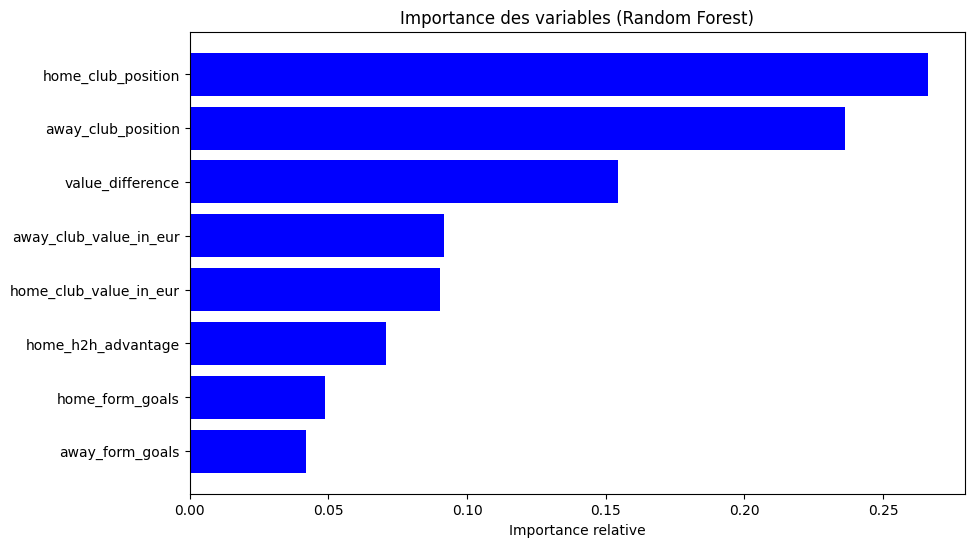

In [20]:
# Analyse de l'importance des variables pour le Random Forest
importances = algo_rf.feature_importances_
features = df_model.drop(columns=['results']).columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importance des variables (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance relative')
plt.show()

In [21]:
# --- TEST 5 : GRADIENT BOOSTING (Le Roi des compétitions) ---
print("\nTEST 5 : GRADIENT BOOSTING")
# Ici, chaque arbre corrige les erreurs de l'arbre précédent !
algo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
predictor_gb = Predictor(dataframe=df_model, model=algo_gb)

predictor_gb.prepare_data()
predictor_gb.train()
predictor_gb.evaluate()


TEST 5 : GRADIENT BOOSTING
Données préparées
Modèle GradientBoostingClassifier entraîné
Accuracy : 56.975505857295 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.63      0.60       281
           0       0.29      0.15      0.20       229
           1       0.63      0.76      0.69       429

    accuracy                           0.57       939
   macro avg       0.50      0.51      0.50       939
weighted avg       0.53      0.57      0.54       939



In [22]:
print("\nTEST 6 : LINEAR SVC ")
algo_lsvc = LinearSVC(max_iter=1000, random_state=42)
predictor_lsvc = Predictor(dataframe=df_model, model=algo_lsvc)

predictor_lsvc.prepare_data()
predictor_lsvc.train()
predictor_lsvc.evaluate()


TEST 6 : LINEAR SVC 
Données préparées
Modèle LinearSVC entraîné
Accuracy : 58.89243876464324 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.69      0.62       281
           0       0.00      0.00      0.00       229
           1       0.60      0.84      0.70       429

    accuracy                           0.59       939
   macro avg       0.39      0.51      0.44       939
weighted avg       0.44      0.59      0.51       939



In [23]:
print("\nTEST 7 : KNN (K-Nearest Neighbors) ")
algo_knn = KNeighborsClassifier(n_neighbors=15)
predictor_knn = Predictor(dataframe=df_model, model=algo_knn)

predictor_knn.prepare_data()
predictor_knn.train()
predictor_knn.evaluate()


TEST 7 : KNN (K-Nearest Neighbors) 
Données préparées
Modèle KNeighborsClassifier entraîné
Accuracy : 55.6975505857295 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.55      0.59      0.57       281
           0       0.29      0.18      0.23       229
           1       0.64      0.73      0.68       429

    accuracy                           0.56       939
   macro avg       0.49      0.50      0.49       939
weighted avg       0.53      0.56      0.54       939



In [24]:
print("\nTEST 8 : RÉSEAU DE NEURONES (MLP) ")
algo_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
predictor_mlp = Predictor(dataframe=df_model, model=algo_mlp)

predictor_mlp.prepare_data()
predictor_mlp.train()
predictor_mlp.evaluate()




TEST 8 : RÉSEAU DE NEURONES (MLP) 
Données préparées
Modèle MLPClassifier entraîné
Accuracy : 51.118210862619804 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.52      0.52      0.52       281
           0       0.26      0.21      0.23       229
           1       0.61      0.66      0.63       429

    accuracy                           0.51       939
   macro avg       0.46      0.47      0.46       939
weighted avg       0.50      0.51      0.50       939



In [25]:
print("\nTEST 9 : NAIVE BAYES")
algo_nb = GaussianNB()
predictor_nb = Predictor(dataframe=df_model, model=algo_nb)

predictor_nb.prepare_data()
predictor_nb.train()
predictor_nb.evaluate()


TEST 9 : NAIVE BAYES
Données préparées
Modèle GaussianNB entraîné
Accuracy : 53.24813631522897 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.51      0.55       281
           0       0.32      0.42      0.36       229
           1       0.66      0.61      0.63       429

    accuracy                           0.53       939
   macro avg       0.52      0.51      0.51       939
weighted avg       0.56      0.53      0.54       939

